# **Final Code Notebook: Integrating Your ML Pipeline**

#### **Project Members**: Isabelle Berkowitz, Farah Ahmed, Poomathi Subramaniam

#### **Course**: DX703 Advanced Machine Learning & AI

#### **Due**: April 26 - No late assignments accepted, we need the time to grade them!**

#### **Purpose**: To have a complete, clean, and reproducible implementation of our project pipeline starting with milestone 1 to creating the final model


#### **Sections Required**

    * A.1: Setup and Context (10 pts) - Provide a brief, clear overview of the project context and the work leading to this final model.

    * A.2: Model Selection and Retraining (30 pts) - You will choose one final model based on your Milestone 2 validation results and retrain it cleanly in this notebook.

    * A.3: Evaluation and Visualization (30 pts) - This section should illustrate how you measured evaluated, and visualized your model’s performance

#### Relevant Packages

In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os, random
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import TextVectorization
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments, AutoTokenizer
import time
# to handle our seed
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
import keras_hub

In [2]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# **A.1: Setup and Context (10 pts)**


## Steps to Follow

### 1. **Summary of Milestones 1 and 2**

    * A short Markdown overview describing major steps you took previously,
including:

        * Data cleaning and preprocessing

        * Feature engineering or augmentation strategies
        
        * Early model experiments in Milestone 2 and what you learned from them


### 2. **Final preprocessing pipeline:**

    * Include all finalized code for:

        * Loading the dataset

        * Cleaning steps (text normalization, image transforms, etc.)

        * Preprocessing (tokenization, resizing, normalization, augmentation, etc.)



### **Step 1 -  Summary of Milestones 1 and 2**




 #### **(i) Project Overview**
This project focuses on a multi-class text classification task using the HuffPost News Category dataset. The goal is to predict the category of a news article based on its headline and short description, combined as: `"headline [SEP] short_description"`. This task is relevant for applications such as automated news categorization, content recommendation, and information retrieval.



#### **(ii) Summary of Milestone 1**

In Milestone 1, we explored two datasets: **Food-101 (image-based)** and **HuffPost News Category (text-based)**. After conducting exploratory data analysis (EDA), we selected the HuffPost dataset due to its relevance to natural language processing, real-world applicability, and diverse category structure. It was also more efficient to load and process, making it suitable for iterative experimentation.

**a) Data Cleaning and Preprocessing:**

The focus in Milestone 1 was on understanding the dataset rather than implementing preprocessing. The dataset contains approximately **200,853 samples across 41 categories**.
We inspected the data for:
- Missing or empty text fields  
- 488 duplicate entries
- Noisy or very short text samples  

We also observed **class imbalance** and **ambiguous labels** (e.g., *POLITICS* vs *WORLD NEWS*, *WELLNESS* vs *HEALTHY LIVING*). Variations in text length further highlighted the need for standardized inputs.
These insights helped define later preprocessing steps such as handling duplicates, addressing imbalance, and preparing text for modeling.






#### **(iii) Summary of Milestone 2**

In Milestone 2, we implemented preprocessing and developed multiple models of increasing complexity.

**a) Data Cleaning and Preprocessing**

- Loaded the dataset using Hugging Face  
- Combined **headline** and **short description** using a **[SEP]** token  
- Used a TextVectorization layer for standardization and tokenization  
- Converted text into integer sequences  
- Applied padding and truncation for consistent input length  
- Removed duplicates and ensured data consistency  
- Created reproducible train/validation/test splits with stratification  

**b) Feature Engineering or Augmentation Strategies**

We focused on transforming text into numerical representations:
- Combined text fields for richer context  
- Used TextVectorization for vocabulary building and sequence generation  
- Selected sequence length based on observed text distribution  
- Used **DistilBERT** for contextual embeddings, improving handling of ambiguity  
No data augmentation was applied, as it is less common for text tasks.

**c) Early Model Experiments and What We Learned:**

We evaluated three models:


- **Baseline model (Farah) :** The baseline model created for the HuffPost dataset is a small embedding-based text classifier. It uses tokenized sequences as input, in which each token is mapped to a 128-dimensional embedding. A GlobalAveragePooling1D layer is added to combine the sequence information. A Dense layer is incorporated with softmax activation for predicting class probabilities. This model structure is suitable for the text dataset as a baseline because it trains quickly and serves as a starting point for evaluating future and more complex models. In the early epochs, the training loss decreases, while the training accuracy increases. Also, the validation loss decreases in the beginning and eventually levels off while the training loss continues to decrease. This indicates that there is slight overfitting occurring, in which the model is beginning to fit the training better than the validation. Overall, the trend shows that the model is learning well, but could be improved with the use of regularization techniques like dropout. The best validation performance occurs at epoch 6, in which the validation loss is 1.6356 and the validation accuracy is 0.5554. For the test set, the validation accuracy is 0.5546 and a macro F1 score of 0.4827. These metric results indicate that the dataset is moderately complex. The model is able to learn patterns from the data, but the accuracy and macro F1 score are low. This suggests that the classification task is challenging. This is likely due to the heavily imbalanced dataset. Also, the gap between the training and validation performances indicates that the model is struggling to generalize well. Based on this, advanced models and tuning is necessary to improve model performance


- **Custom model (Poomathi):** The custom model extends the baseline by adding an Embedding layer, Global Average Pooling, Batch Normalization, a Dense (ReLu) Layer, Dropout (0.5), and a Softmax output layer. It was trained using the Adam optimizer, sparse categorical cross-entropy loss, early stopping and class weights to handle class imbalance. These additions aimed to improve learning stability, reduce overfitting, and capture more complex patterns in the data. The model achieved the test accuracy of 0.5299 and a macro F1-score of 0.4567, slightly lower than the baseline model. Training accuracy improved over epochs, but validation performance plateaued, indicating overfitting. This showed that while architectural improvements help, traditional embedding based models still struggle with conceptual understanding, motivating the use of pretrained models. Overall, this experiment highlighted the need for more advanced models to better understand context and improve performance.


- **Pretrained DistilBERT model (Isabelle):** We selected **DistilBERT** as our pretrained architecture given it was smaller and takes less computation time compared to BERT, while retaining very similar results. We used fine-tuning and tested with learning rates **2e-5** and **3e-5**, though, **2e-5** gave us better results (**0.6426**  vs. **0.6383**). We added hyperparmeters: early stopping, patience = 3, and class weights help address the significant class imbalance. We ran two experiments that both took just over 8 minutes for 3 epochs, which is significantly longer than the baseline.








#### **Step 2) Final Preprocessing Pipeline**

    (i) load in the dataset

In [3]:
# Your code here, add as many cells as you like. Provide organization and structure by appropriate comments, labels, and variable names. Explain what
# you are doing in case you come back to this in a year.
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print("Total samples:", len(huff_all))
print("Columns:", huff_all.column_names)

df = pd.DataFrame(huff_all)
df["text"] = df["headline"].fillna('') + " [SEP] " + df["short_description"].fillna('')

# strip whitespace and lowercase
df['text'] = df['text'].str.strip().str.lower()
df.head(5)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Total samples: 200853
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']


,category,headline,authors,link,short_description,date,text
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26,there were 2 mass shootings in texas last week...
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26,will smith joins diplo and nicky jam for the 2...
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26,hugh grant marries for the first time at age 5...
3,ENTERTAINMENT,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,Ron Dicker,https://www.huffingtonpost.com/entry/jim-carre...,The actor gives Dems an ass-kicking for not fi...,2018-05-26,jim carrey blasts 'castrato' adam schiff and d...
4,ENTERTAINMENT,Julianna Margulies Uses Donald Trump Poop Bags...,Ron Dicker,https://www.huffingtonpost.com/entry/julianna-...,"The ""Dietland"" actress said using the bags is ...",2018-05-26,julianna margulies uses donald trump poop bags...


    (ii) Apply Cleaning Outlined From Milestone 1

In [4]:
# 1) Drop the 488 duplicates
initial_len = len(df)
df = df.drop_duplicates(subset=["text"])
print("After dropping duplicates:", len(df))
print("Duplicates remaining:", df.duplicated(subset=["text"]).sum())

# 2) Remove any empty texts
df = df[df["text"].str.strip() != ""]
print("After dropping empty texts:", len(df))
print("Empty texts remaining:", (df["text"].str.strip() == "").sum())

# 3) Remove the short texts
df = df[df["text"].apply(lambda x: len(x.split())) > 3]
print("After dropping short texts:", len(df))
print("Short texts remaining:", (df["text"].apply(lambda x: len(x.split())) <= 3).sum())

After dropping duplicates: 200358
Duplicates remaining: 0
After dropping empty texts: 200358
Empty texts remaining: 0
After dropping short texts: 200158
Short texts remaining: 0


    (iii) Label Encoding + Splits

In [5]:
label_enc = LabelEncoder() # encode the labels as integers for better interpretability
df["label"] = label_enc.fit_transform(df["category"])

num_classes = len(np.unique(df["label"]))
print("Number of classes:", num_classes)

# implement a stratefied split
train_data, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['label'])

# split the temp into 10% val and 10% test
val_data, test_data = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"])


# display the sizes of each subset
print(f"Train size:      {len(train_data)}")
print(f"Validation size: {len(val_data)}")
print(f"Test size:       {len(test_data)}")

Number of classes: 41
Train size:      160126
Validation size: 20016
Test size:       20016


    (iv) Handle Class Imbalance With Weights

In [6]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data['label']),
    y=train_data['label'])
class_weights_dict = dict(enumerate(weights))

    (v) Why no Tokenization Here

In Milestone 2 we set up tokenization when we prepared and split the data. However, our best model was from DistilBERT which does tokenization through the **keras_hub** preprocessor. This will be done in A.2 with 'MAX_LENGTH' defined.

## A.2: Model Selection and Retraining (30 pts)


### Steps to Follow

1. **Run DistilBERT**
  * Run the base model

  * Run new models

2. **Final architecture and justification (Markdown + code):**

    * Clearly state what architecture you selected (CNN, pretrained encoder,
TF-IDF + dense, etc.)

    * Briefly explain the method and metrics used to select your final model (a
fuller explanation will be provided in the Project Report)



3. **Hyperparameter definitions:**

    * Clearly document the values for:

        * Learning rate and LR schedulers

        * Batch size

        * Number of epochs

        * Dropout Rates

        * Weight decay / L2 regularization (if any)

4. **Optimization strategy:**

    * Show the optimizer configuration and describe why it is appropriate (e.g., Adam
for stability, SGD + momentum, etc.).

5. **Callbacks**

    * Include any callbacks used during training (early stopping, checkpointing, LR
scheduler)

* Briefly explain how these helped prevent overfitting or improve training stability.


6. **Retraining from scratch:**

    * Run the full training loop using:

        * The entire training set

        * A held-out validation split

        * A separate test set reserved for final evaluation


### **Step 1A -  Run the base DistilBERT (BEST FROM MILESTONE 2)**

    (i) adapt the model

In [7]:
MAX_LENGTH = 60

preprocessor = keras_hub.models.DistilBertTextClassifierPreprocessor.from_preset(
    "distil_bert_base_en_uncased",
    sequence_length=MAX_LENGTH)

# 3) load in the classifier for the 41 categories
distilbert_model = keras_hub.models.DistilBertTextClassifier.from_preset(
    "distil_bert_base_en_uncased",
    num_classes=num_classes,
    preprocessor=preprocessor,
    activation="softmax")

100%|██████████| 794/794 [00:00<00:00, 1.31MB/s]


    (ii) Apply Transfer Learning



In [8]:
distilbert_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

    (iii) Train and Evaluate

In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True)

start = time.time()
history_distilbert = distilbert_model.fit(
    x=train_data["text"].values,
    y=train_data["label"].values,
    validation_data=(
        val_data["text"].values,
        val_data["label"].values),
    batch_size=32,
    epochs=3,
    class_weight=class_weights_dict,
    callbacks=[early_stop])
elapsed = time.time() - start
print(f"Training time: {time.strftime('%H:%M:%S', time.gmtime(elapsed))}")

Epoch 1/3
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 243s 38ms/step - accuracy: 0.5416 - loss: 1.6968 - val_accuracy: 0.6129 - val_loss: 1.3386
Epoch 2/3
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 136s 27ms/step - accuracy: 0.6444 - loss: 1.1019 - val_accuracy: 0.6395 - val_loss: 1.2197
Epoch 3/3
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 135s 27ms/step - accuracy: 0.6963 - loss: 0.8516 - val_accuracy: 0.6459 - val_loss: 1.2227
Training time: 00:08:35


    (iv) Create Plots

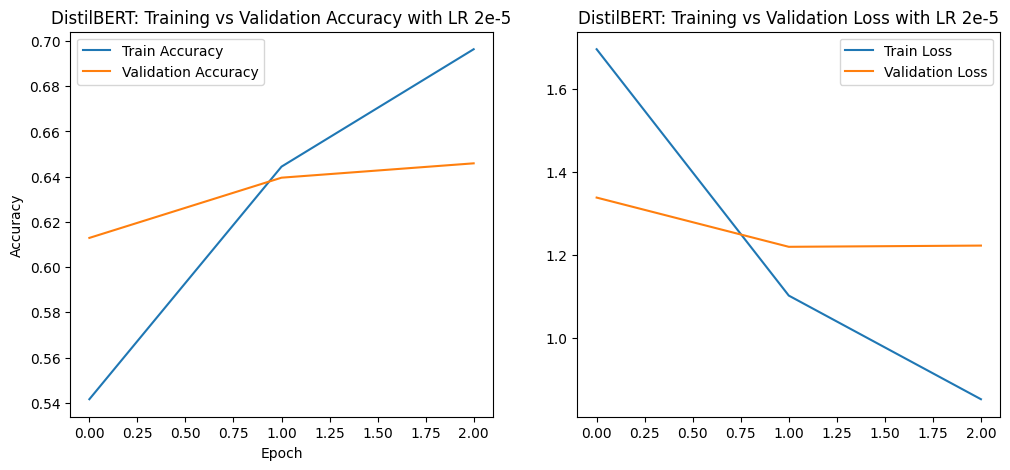

In [10]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_distilbert.history['accuracy'], label='Train Accuracy')
plt.plot(history_distilbert.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('DistilBERT: Training vs Validation Accuracy with LR 2e-5')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_distilbert.history['loss'], label='Train Loss')
plt.plot(history_distilbert.history['val_loss'], label='Validation Loss')
plt.title('DistilBERT: Training vs Validation Loss with LR 2e-5')
plt.legend()
plt.show()

    (v) Compare and Analyze

In [11]:
from sklearn.metrics import f1_score
test_loss_d, test_acc_d = distilbert_model.evaluate(
    test_data["text"].values,
    test_data["label"].values)


y_pred_distil = distilbert_model.predict(test_data["text"].values)
y_pred_distil_arg = y_pred_distil.argmax(axis=-1)
f1_d = f1_score(test_data["label"].values, y_pred_distil_arg, average="macro")

print(f"DistilBERT Test Accuracy: {test_acc_d:.4f}")
print(f"DistilBERT Macro F1:      {f1_d:.4f}")

626/626 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6386 - loss: 1.2259
626/626 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step
DistilBERT Test Accuracy: 0.6386
DistilBERT Macro F1:      0.5730


### **Step 1B -  Run Different Experiments With Different Hyperparameters**

- the following experiments capture the changes our group has made to retrain our baseline model to improve the overall results.

- we experimented with different hyperparameters, optimization strategies, and callbacks

#### **Experiment 2: AdamW + Weight Decay + Monitor Val Accuracy**

- This is different from the baseline, because we switched **Adam** for **AdamW** and added weight_decay=0.01 to add L2 regularization. We also switched early stopping to monitor **val_accuracy** instead of **val_loss**. In our baseline, the validation loss began diverging while the validation accuracy was improving, therefore loss was no longer reliable for stopping the signal. The results showed **0.6472 (accuracy) with 0.5815 (test f1)**

In [21]:
MAX_LENGTH = 60 # same as the best model from M2

LEARNING_RATE = 2e-5 # same as the best model from M2

WEIGHT_DECAY = 0.01 # NEW

BATCH_SIZE = 32 # same as the best model from M2

EPOCHS = 8 # NEW: INCREASED 3 -> 8

PATIENCE = 3 # same as the best model from M2

preprocessor_exp2 = keras_hub.models.DistilBertTextClassifierPreprocessor.from_preset(
    "distil_bert_base_en_uncased",
    sequence_length=MAX_LENGTH)

model_exp2 = keras_hub.models.DistilBertTextClassifier.from_preset(
    "distil_bert_base_en_uncased",
    num_classes=num_classes,
    preprocessor=preprocessor_exp2,
    activation="softmax")

# HERE WE USED AdamW INSTEAD OF Adam

# Apply Transfer Learning
model_exp2.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

# Train and Evaluate
early_stop_exp2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", # we monitored validation accuracy
    patience=PATIENCE,
    restore_best_weights=True,
    mode="max")

start = time.time()
history_exp2 = model_exp2.fit(
    x=train_data["text"].values,
    y=train_data["label"].values,
    validation_data=(val_data["text"].values, val_data["label"].values),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    class_weight=class_weights_dict,
    callbacks=[early_stop_exp2])
elapsed = time.time() - start
print(f"Training time: {time.strftime('%H:%M:%S', time.gmtime(elapsed))}")

test_loss_exp2, test_acc_exp2 = model_exp2.evaluate(
    test_data["text"].values, test_data["label"].values)
y_pred_exp2 = model_exp2.predict(test_data["text"].values).argmax(axis=-1)
f1_exp2 = f1_score(test_data["label"].values, y_pred_exp2, average="macro")

print(f"Exp2 Test Accuracy: {test_acc_exp2:.4f}")
print(f"Exp2 Macro F1:      {f1_exp2:.4f}")

100%|██████████| 253M/253M [00:08<00:00, 32.7MB/s]


Epoch 1/8
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 216s 35ms/step - accuracy: 0.5399 - loss: 1.6961 - val_accuracy: 0.6177 - val_loss: 1.3135
Epoch 2/8
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 141s 28ms/step - accuracy: 0.6443 - loss: 1.1024 - val_accuracy: 0.6421 - val_loss: 1.2143
Epoch 3/8
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 140s 28ms/step - accuracy: 0.6962 - loss: 0.8538 - val_accuracy: 0.6489 - val_loss: 1.2098
Epoch 4/8
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 142s 28ms/step - accuracy: 0.7392 - loss: 0.6609 - val_accuracy: 0.6544 - val_loss: 1.2345
Epoch 5/8
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 141s 28ms/step - accuracy: 0.7763 - loss: 0.5139 - val_accuracy: 0.6614 - val_loss: 1.2953
Epoch 6/8
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 141s 28ms/step - accuracy: 0.8068 - loss: 0.4005 - val_accuracy: 0.6684 - val_loss: 1.3179
Epoch 7/8
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 140s 28ms/step - accuracy: 0.8348 - loss: 0.3149 - val_accuracy: 0.6467 - val_loss: 1.4692
Epoch 8/8
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 140s 28ms/step - accuracy: 0.8550 -

#### **Experiment 3 : Longer max_length + AdamW + monitor val_accuracy**

This is different from experiment 2, because we increased MAX_LENGTH from 60 to 128, keeping **AdamW** and added weight_decay=0.01 to add L2 regularization. 60 represented the token limit based on the 95th percentile of a  TextVectorization split but not for the DistilBERT tokenizer. We also kept the switch for early stopping to monitor **val_accuracy** instead of **val_loss**. This helped improve the results **0.6690 (accuracy) with 0.5900 (test f1)**

In [13]:
MAX_LENGTH = 128 # NEW: increased from 60 -> 128

LEARNING_RATE = 2e-5 # same as the best model from M2

WEIGHT_DECAY = 0.01 # NEW

BATCH_SIZE = 32 # same as the best model from M2

EPOCHS = 8 #NEW

PATIENCE = 3 # same as the best model from M2

preprocessor_exp3 = keras_hub.models.DistilBertTextClassifierPreprocessor.from_preset(
    "distil_bert_base_en_uncased",
    sequence_length=MAX_LENGTH)

model_exp3 = keras_hub.models.DistilBertTextClassifier.from_preset(
    "distil_bert_base_en_uncased",
    num_classes=num_classes,
    preprocessor=preprocessor_exp3,
    activation="softmax")

# HERE WE USED AdamW INSTEAD OF Adam

# Apply Transfer Learning
model_exp3.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])


# Train and Evaluate
early_stop_exp3 = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", # we monitored validation accuracy
    patience=PATIENCE,
    restore_best_weights=True,
    mode="max")

start = time.time()
history_exp3 = model_exp3.fit(
    x=train_data["text"].values,
    y=train_data["label"].values,
    validation_data=(val_data["text"].values, val_data["label"].values),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    class_weight=class_weights_dict,
    callbacks=[early_stop_exp3])
elapsed = time.time() - start
print(f"Training time: {time.strftime('%H:%M:%S', time.gmtime(elapsed))}")

test_loss_exp3, test_acc_exp3 = model_exp3.evaluate(
    test_data["text"].values, test_data["label"].values)
y_pred_exp3 = model_exp3.predict(test_data["text"].values).argmax(axis=-1)
f1_exp3 = f1_score(test_data["label"].values, y_pred_exp3, average="macro")
print(f"Exp3 Test Accuracy: {test_acc_exp3:.4f}")
print(f"Exp3 Macro F1:      {f1_exp3:.4f}")

Epoch 1/8
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 300s 48ms/step - accuracy: 0.5461 - loss: 1.6761 - val_accuracy: 0.6155 - val_loss: 1.3193
Epoch 2/8
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 184s 37ms/step - accuracy: 0.6461 - loss: 1.0876 - val_accuracy: 0.6428 - val_loss: 1.2087
Epoch 3/8
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 184s 37ms/step - accuracy: 0.6992 - loss: 0.8411 - val_accuracy: 0.6530 - val_loss: 1.1983
Epoch 4/8
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 184s 37ms/step - accuracy: 0.7427 - loss: 0.6481 - val_accuracy: 0.6677 - val_loss: 1.2008
Epoch 5/8
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 186s 37ms/step - accuracy: 0.7793 - loss: 0.5035 - val_accuracy: 0.6603 - val_loss: 1.2747
Epoch 6/8
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 186s 37ms/step - accuracy: 0.8098 - loss: 0.3943 - val_accuracy: 0.6705 - val_loss: 1.3218
Epoch 7/8
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 184s 37ms/step - accuracy: 0.8359 - loss: 0.3128 - val_accuracy: 0.6718 - val_loss: 1.3470
Epoch 8/8
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 184s 37ms/step - accuracy: 0.8584 -

#### **Experiment 4: AdamW + Max Length 128 + Lower Learning Rate (1e-5) + More Epochs**

Here we reduced the learning rate from 2e-5 to 1e-5 and increased epochs
to 10, keeping max_length=128 and AdamW from exp3. In exp 3, there was a lot of overfitting present by the time the model reach epoch 8 and the validation accuracy was still increasing. So we decided to increase epoch from 8 -> 10 and se if accuracy improves (which it did). This gave us **0.6703 (acc) and 0.5970 (f1)**

In [14]:
MAX_LENGTH = 128 #same as exp 3

LEARNING_RATE = 1e-5   # NEW updated from 2e-5

WEIGHT_DECAY = 0.01 # NEW

BATCH_SIZE = 32 # same as the best model from M2

EPOCHS = 10  # NEW: 8 -> 10

PATIENCE = 3 # same as the best model from M2

preprocessor_exp4 = keras_hub.models.DistilBertTextClassifierPreprocessor.from_preset(
    "distil_bert_base_en_uncased",
    sequence_length=MAX_LENGTH)

model_exp4 = keras_hub.models.DistilBertTextClassifier.from_preset(
    "distil_bert_base_en_uncased",
    num_classes=num_classes,
    preprocessor=preprocessor_exp4,
    activation="softmax")

# Apply Transfer Learning
model_exp4.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])


#Train and Evaluate
early_stop_exp4 = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=PATIENCE,
    restore_best_weights=True,
    mode="max")

start = time.time()
history_exp4 = model_exp4.fit(
    x=train_data["text"].values,
    y=train_data["label"].values,
    validation_data=(val_data["text"].values, val_data["label"].values),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    class_weight=class_weights_dict,
    callbacks=[early_stop_exp4])
elapsed = time.time() - start
print(f"Training time: {time.strftime('%H:%M:%S', time.gmtime(elapsed))}")

test_loss_exp4, test_acc_exp4 = model_exp4.evaluate(
    test_data["text"].values, test_data["label"].values)
y_pred_exp4 = model_exp4.predict(test_data["text"].values).argmax(axis=-1)
f1_exp4 = f1_score(test_data["label"].values, y_pred_exp4, average="macro")
print(f"Exp4 Test Accuracy: {test_acc_exp4:.4f}")
print(f"Exp4 Macro F1:      {f1_exp4:.4f}")

Epoch 1/10
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 266s 44ms/step - accuracy: 0.5125 - loss: 1.9273 - val_accuracy: 0.5991 - val_loss: 1.4133
Epoch 2/10
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 187s 37ms/step - accuracy: 0.6157 - loss: 1.2373 - val_accuracy: 0.6324 - val_loss: 1.2582
Epoch 3/10
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 186s 37ms/step - accuracy: 0.6563 - loss: 1.0327 - val_accuracy: 0.6478 - val_loss: 1.2119
Epoch 4/10
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 188s 37ms/step - accuracy: 0.6880 - loss: 0.8746 - val_accuracy: 0.6515 - val_loss: 1.2107
Epoch 5/10
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 187s 37ms/step - accuracy: 0.7196 - loss: 0.7400 - val_accuracy: 0.6478 - val_loss: 1.2283
Epoch 6/10
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 187s 37ms/step - accuracy: 0.7465 - loss: 0.6230 - val_accuracy: 0.6548 - val_loss: 1.2440
Epoch 7/10
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 186s 37ms/step - accuracy: 0.7714 - loss: 0.5263 - val_accuracy: 0.6563 - val_loss: 1.2789
Epoch 8/10
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 186s 37ms/step - accuracy: 

In [22]:
results_df = pd.DataFrame({
    'Experiment': ['Baseline (M2)', 'Exp 2', 'Exp 3', 'Exp 4'],
    'Test Accuracy': [test_acc_d, test_acc_exp2, test_acc_exp3, test_acc_exp4],
    'Macro F1': [f1_d, f1_exp2, f1_exp3, f1_exp4]})


print(results_df.to_string(index=False))
best_idx_acc = results_df['Test Accuracy'].idxmax()
best_idx_f1 = results_df['Macro F1'].idxmax()

print(f"\nBest by Accuracy: {results_df.loc[best_idx_acc, 'Experiment']} ({results_df.loc[best_idx_acc, 'Test Accuracy']:.4f})")
print(f"Best by F1: {results_df.loc[best_idx_f1, 'Experiment']} ({results_df.loc[best_idx_f1, 'Macro F1']:.4f})")

   Experiment  Test Accuracy  Macro F1
Baseline (M2)       0.638639  0.572969
        Exp 2       0.667316  0.590166
        Exp 3       0.667766  0.591591
        Exp 4       0.672962  0.597273

Best by Accuracy: Exp 4 (0.6730)
Best by F1: Exp 4 (0.5973)


### **Step 2 -  Final Architecture and Justification**

 **(i) What architecture we selected (prior):**
   Our final Architecture was a DistilBERT Model based on the results from Milestone 2, where we built three separate models:

 1) **baseline:** Embedding + GlobalAveragePooling
 2) **custom:** BiGRU models experimented with different learning rates
 3) **pretrained model:** fine-tuned DistilBERT model (lr: 2e-5 vs 3e-5)


 These three models revealed that the pretrained DistilBERT model was the best. In milestone 2, this model achieved: **accuracy = 0.6426 & f1 = 0.5779**; however, when we re-ran the model in the final notebook, it updated to **accuracy = 0.6386 & f1 = 0.5730**.




 **(ii) Explain the methods and metrics used (currently):**


In step 1, we ran four separate experiments. We first ran our original DistilBERT model and then ran three more tuning different parameters to improve performance:


**EXP 2**: AdamW, weight_decay=0.01, monitor val_accuracy obtaining acc = 0.6673 & f1 = 0.5901


**EXP 3**: Same as Exp 2 but max_length=128 and acc = 0.6678 & f1 = 0.5916


**EXP 4**: Same as Exp 3 but lr=1e-5, epochs=10 and acc = 0.6723& f1 = 0.5972


**Experiment 4** produced the best results and was selected as our final configuration. We included detailed descriptions of the changes in certain parameters under their experiment titles.


### **Step 3 - Hyperparameters Used:**

The hyperparameter combination below represents the parameters used in our best experiment (exp 4)

**MAX_LENGTH = 128** -> increased from 60 to 128 to better capture the full headline + short description context

**LEARNING_RATE = 1e-5** -> Reduced from 2e-5 to help slow down the updates and reduce the overfitting when the validation accuracy was still increasing, while validation loss was diverging

**WEIGHT_DECAY = 0.01** -> Including L2 regularization with **AdamW** to help improve model generalization

**BATCH_SIZE = 32** -> Same across all models in final project & milestone 2

**EPOCHS = 10** -> Increased for more training time, given the lower LR & the overfitting from the validation loss we saw in experiment 3

**PATIENCE = 3** -> Consistent across all models from M2 + Final Project

**Dropouts** = Default DistilBERT dropout = 0.1 (did not modify)



### **Step 4 -  Optimization Strategy**

**(i) Configuration**


Optimizer: AdamW (learning_rate=1e-5, weight_decay=0.01)




**(ii) Why is it appropriate?**


We decided to use **AdamW** instead of Adam, because it is the standard optimizer for fine-tuning transformer models. It allowed us to add proper weight decay, which the baseline model did not include, and acts as L2 regularization. This helped ensure our model was properly generalizing the results and process at each epoch. The earlier experiments showed overfitting from the validation loss while validation accuracy was increasing, so we thought it was best to drop the learning rate from **2e-5 -> 1e-5**. This helped reduce overfitting by slowing down the results from the epochs, giving us our best results.


### **Step 5 -  Callbacks used during training**

**EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True, mode="max")**

We used early stopping monitoring val_accuracy rather than val_loss based on the patterns from the baseline model. We noticed that the validation loss began diverging while the validation accuracy was improving; therefore, the loss was no longer reliable for stopping the signal. By switching to validation accuracy, our model was able to keep training as long as it was still improving results in the validation set. We kept the **restore_best_weights=True** parameter across the baseline and four experiments to ensure the models used the weights from the best epoch rather than the last.


### **Step 6 - Retraining the Model from Scratch**

In [23]:
# the best parameter combination which is from exp 4
MAX_LENGTH = 128
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 32
EPOCHS = 10
PATIENCE = 3

# load the preprocessor and model
final_preprocessor = keras_hub.models.DistilBertTextClassifierPreprocessor.from_preset(
    "distil_bert_base_en_uncased",
    sequence_length=MAX_LENGTH)

final_model = keras_hub.models.DistilBertTextClassifier.from_preset(
    "distil_bert_base_en_uncased",
    num_classes=num_classes,
    preprocessor=final_preprocessor,
    activation="softmax")

final_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

#### **A) The Entire Training Set + B) A Held-out Validation Split**

In [24]:
early_stop_final = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=PATIENCE,
    restore_best_weights=True,
    mode="max")

start = time.time()
history_final = final_model.fit(
    x=train_data["text"].values,
    y=train_data["label"].values,
    validation_data=(
        val_data["text"].values,
        val_data["label"].values),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    class_weight=class_weights_dict,
    callbacks=[early_stop_final])
elapsed = time.time() - start
print(f"Training time: {time.strftime('%H:%M:%S', time.gmtime(elapsed))}")

Epoch 1/10
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 270s 45ms/step - accuracy: 0.5132 - loss: 1.9209 - val_accuracy: 0.5974 - val_loss: 1.4167
Epoch 2/10
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 189s 38ms/step - accuracy: 0.6156 - loss: 1.2322 - val_accuracy: 0.6286 - val_loss: 1.2741
Epoch 3/10
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 191s 38ms/step - accuracy: 0.6550 - loss: 1.0310 - val_accuracy: 0.6342 - val_loss: 1.2285
Epoch 4/10
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 190s 38ms/step - accuracy: 0.6892 - loss: 0.8715 - val_accuracy: 0.6351 - val_loss: 1.2487
Epoch 5/10
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 190s 38ms/step - accuracy: 0.7182 - loss: 0.7385 - val_accuracy: 0.6511 - val_loss: 1.2217
Epoch 6/10
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 190s 38ms/step - accuracy: 0.7464 - loss: 0.6229 - val_accuracy: 0.6564 - val_loss: 1.2464
Epoch 7/10
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 190s 38ms/step - accuracy: 0.7695 - loss: 0.5262 - val_accuracy: 0.6610 - val_loss: 1.2619
Epoch 8/10
5004/5004 ━━━━━━━━━━━━━━━━━━━━ 191s 38ms/step - accuracy: 

#### C) **Seperate Test for Final Evaluation**

In [25]:
# Final evaluation on separate held-out test set
test_loss_final, test_acc_final = final_model.evaluate(
    test_data["text"].values, # ensure that the TEST values are being called for evaluation
    test_data["label"].values) # ensure that the TEST values are being called for evaluation

y_pred_final = final_model.predict(test_data["text"].values).argmax(axis=-1)
f1_final = f1_score(test_data["label"].values, y_pred_final, average="macro")

print(f"Final Model Test Accuracy: {test_acc_final:.4f}")
print(f"Final Model Macro F1:      {f1_final:.4f}")

626/626 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6652 - loss: 1.2892
626/626 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step
Final Model Test Accuracy: 0.6652
Final Model Macro F1:      0.5927


#### D) **Final Model Comparison**

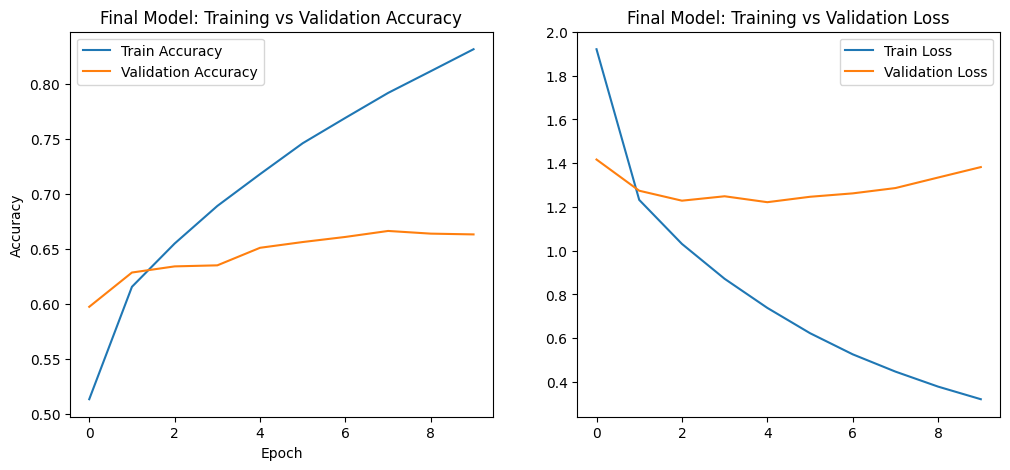

In [26]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_final.history['accuracy'], label='Train Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Final Model: Training vs Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_final.history['loss'], label='Train Loss')
plt.plot(history_final.history['val_loss'], label='Validation Loss')
plt.title('Final Model: Training vs Validation Loss')
plt.legend()
plt.show()

#### E) **Combined accuracy & f1 scores across experiments**

- this table includes all of the accuracies and f1-scores we achieved across this final project

- it includes the baseline model from m2, the three new experiments, and the final model

In [27]:
final_df = pd.DataFrame({
    'Experiment': ['Baseline (M2)', 'Exp 2', 'Exp 3', 'Exp 4', 'Final Model'],
    'Test Accuracy': [test_acc_d, test_acc_exp2, test_acc_exp3, test_acc_exp4, test_acc_final],
    'Macro F1': [f1_d, f1_exp2, f1_exp3, f1_exp4, f1_final]})


print(final_df.to_string(index=False))
best_idx_acc = final_df['Test Accuracy'].idxmax()
best_idx_f1 = final_df['Macro F1'].idxmax()

print(f"\nBest by Accuracy: {final_df.loc[best_idx_acc, 'Experiment']} ({final_df.loc[best_idx_acc, 'Test Accuracy']:.4f})")
print(f"Best by F1: {final_df.loc[best_idx_f1, 'Experiment']} ({final_df.loc[best_idx_f1, 'Macro F1']:.4f})")

   Experiment  Test Accuracy  Macro F1
Baseline (M2)       0.638639  0.572969
        Exp 2       0.667316  0.590166
        Exp 3       0.667766  0.591591
        Exp 4       0.672962  0.597273
  Final Model       0.665168  0.592749

Best by Accuracy: Exp 4 (0.6730)
Best by F1: Exp 4 (0.5973)


## A.3: Evaluation and Visualization (30 pts)

### Steps to Follow

1. **Explanation of evaluation strategy**

    * How the validation split was used?

    * How the test set was kept separate

    * What metrics are appropriate? macro-F1, weighted-F1, accuracy, etc.?


2. **Required plots and printouts:**

    * Training vs. validation loss curves

    * Training vs. validation accuracy (or other metric)

    * Confusion matrix on the test set

    * Any dataset-specific evaluations (per-class metrics tables, F1 score
tables, etc.)


3. **Final Test Metrics:**

    * Include a clean printout of the final test performance (accuracy/per-class
metrics/etc.)


## **Step 1 - Explanation of evaluation strategies**

  **(i) How the validation was split**


The validation set was used during training to monitor and evaluate model performance after each epoch, containing 20,016 samples. We used early stopping to track validation accuracy with patience = 3, meaning training would stop if the validation accuracy did not improve for 3 consecutive epochs. By keeping restore_best_weights=True in the retrained model, it ensured that it used the weights from the best epoch rather than the last one.


  **(ii) How the test set was kept separate**


The test set which contained 20,016 samples was held **completely separate** throughout the entire process. It was not used during training, validation, or while tuning hypermeters for further experiments. In the beginning of milestone 2 and in this final project we created the 80/10/10 stratified split before we pre-processed or did any tokenization to prevent data leakage. The test set was only used at the end of our project to report final model performance




  **(iii) What metrics are appropriate**


This dataset contains 41 categories that are severely imbalanced, which you can see in our third test below ((Any dataset-specific evaluations). This table represents a per-class F1 table, which shows which of the 41 categories the model could handle and which it struggled with. **POLITICS** has **3,270** test samples while **EDUCATION** only has **101**. This difference is very similar to our findings in milestone 1 when we compared the distributions between categories. Accuracy alone is not enough for us to draw conclusions, so we measured three.


1) Macro F1 - This is treating all of the 41 categories in this dataset equally, despite the large differences between some of them. It represents the primary metric for evaluating performance across the underrepresented categories like: EDUCATION, LATINO VOICE, ENVIRONMENT, COLLEGE


2) Weighted F1 - This accounts of class size and allows us to get a better picture for the overall model performance


3) Accuracy - Represents the overall proportion of correct predictions across all the samples



## **Step 2 - Required Plots**

    (i) Training vs. validation accuracy (left) & Training vs. validation loss curves (right)

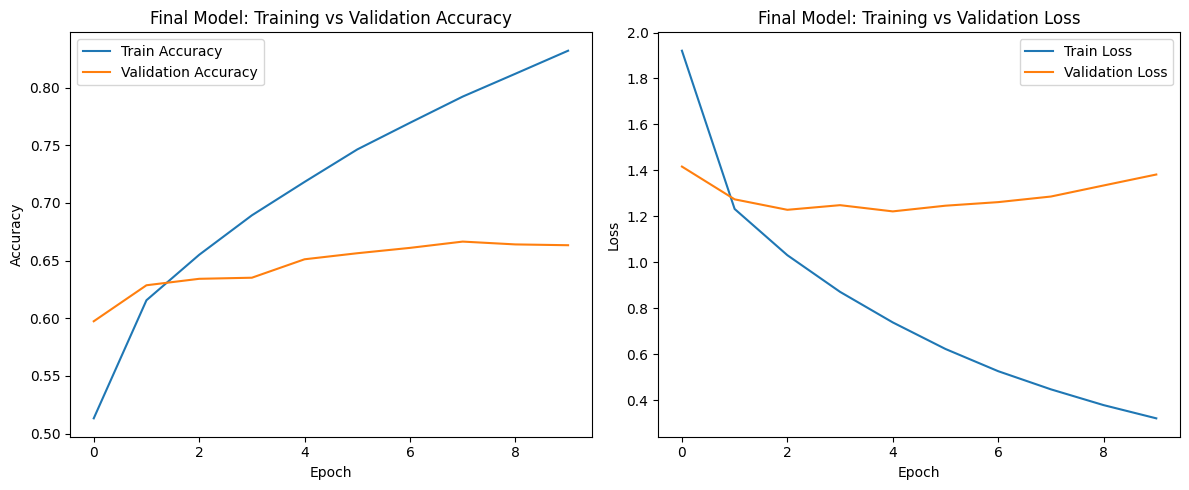

In [33]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_final.history['accuracy'], label='Train Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Final Model: Training vs Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_final.history['loss'], label='Train Loss')
plt.plot(history_final.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final Model: Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

- The Training vs. Validation Accuracy plot (left) shows that training accuracy increased the whole time while validation accuracy flattened around epoch 3-4. This reflects that despite our efforts to tune the model, having 41 categories, some of which are very similar, ends in overfitting


- The training vs. validation loss (right) shows that val loss starts increasing back up around epoch 2, even while val accuracy was still improving. This validates our decisions to switch from monitoring val loss to val accuracy.


    (ii) Confusion matrix on the test set

- the original confusion matrix was very difficult to analyze so we decided to use Log Norm to improve quality

- there are no numbers given the crazy amount of categories we are working with, so we decided to extract the top 10 confusion pairs to validate these results

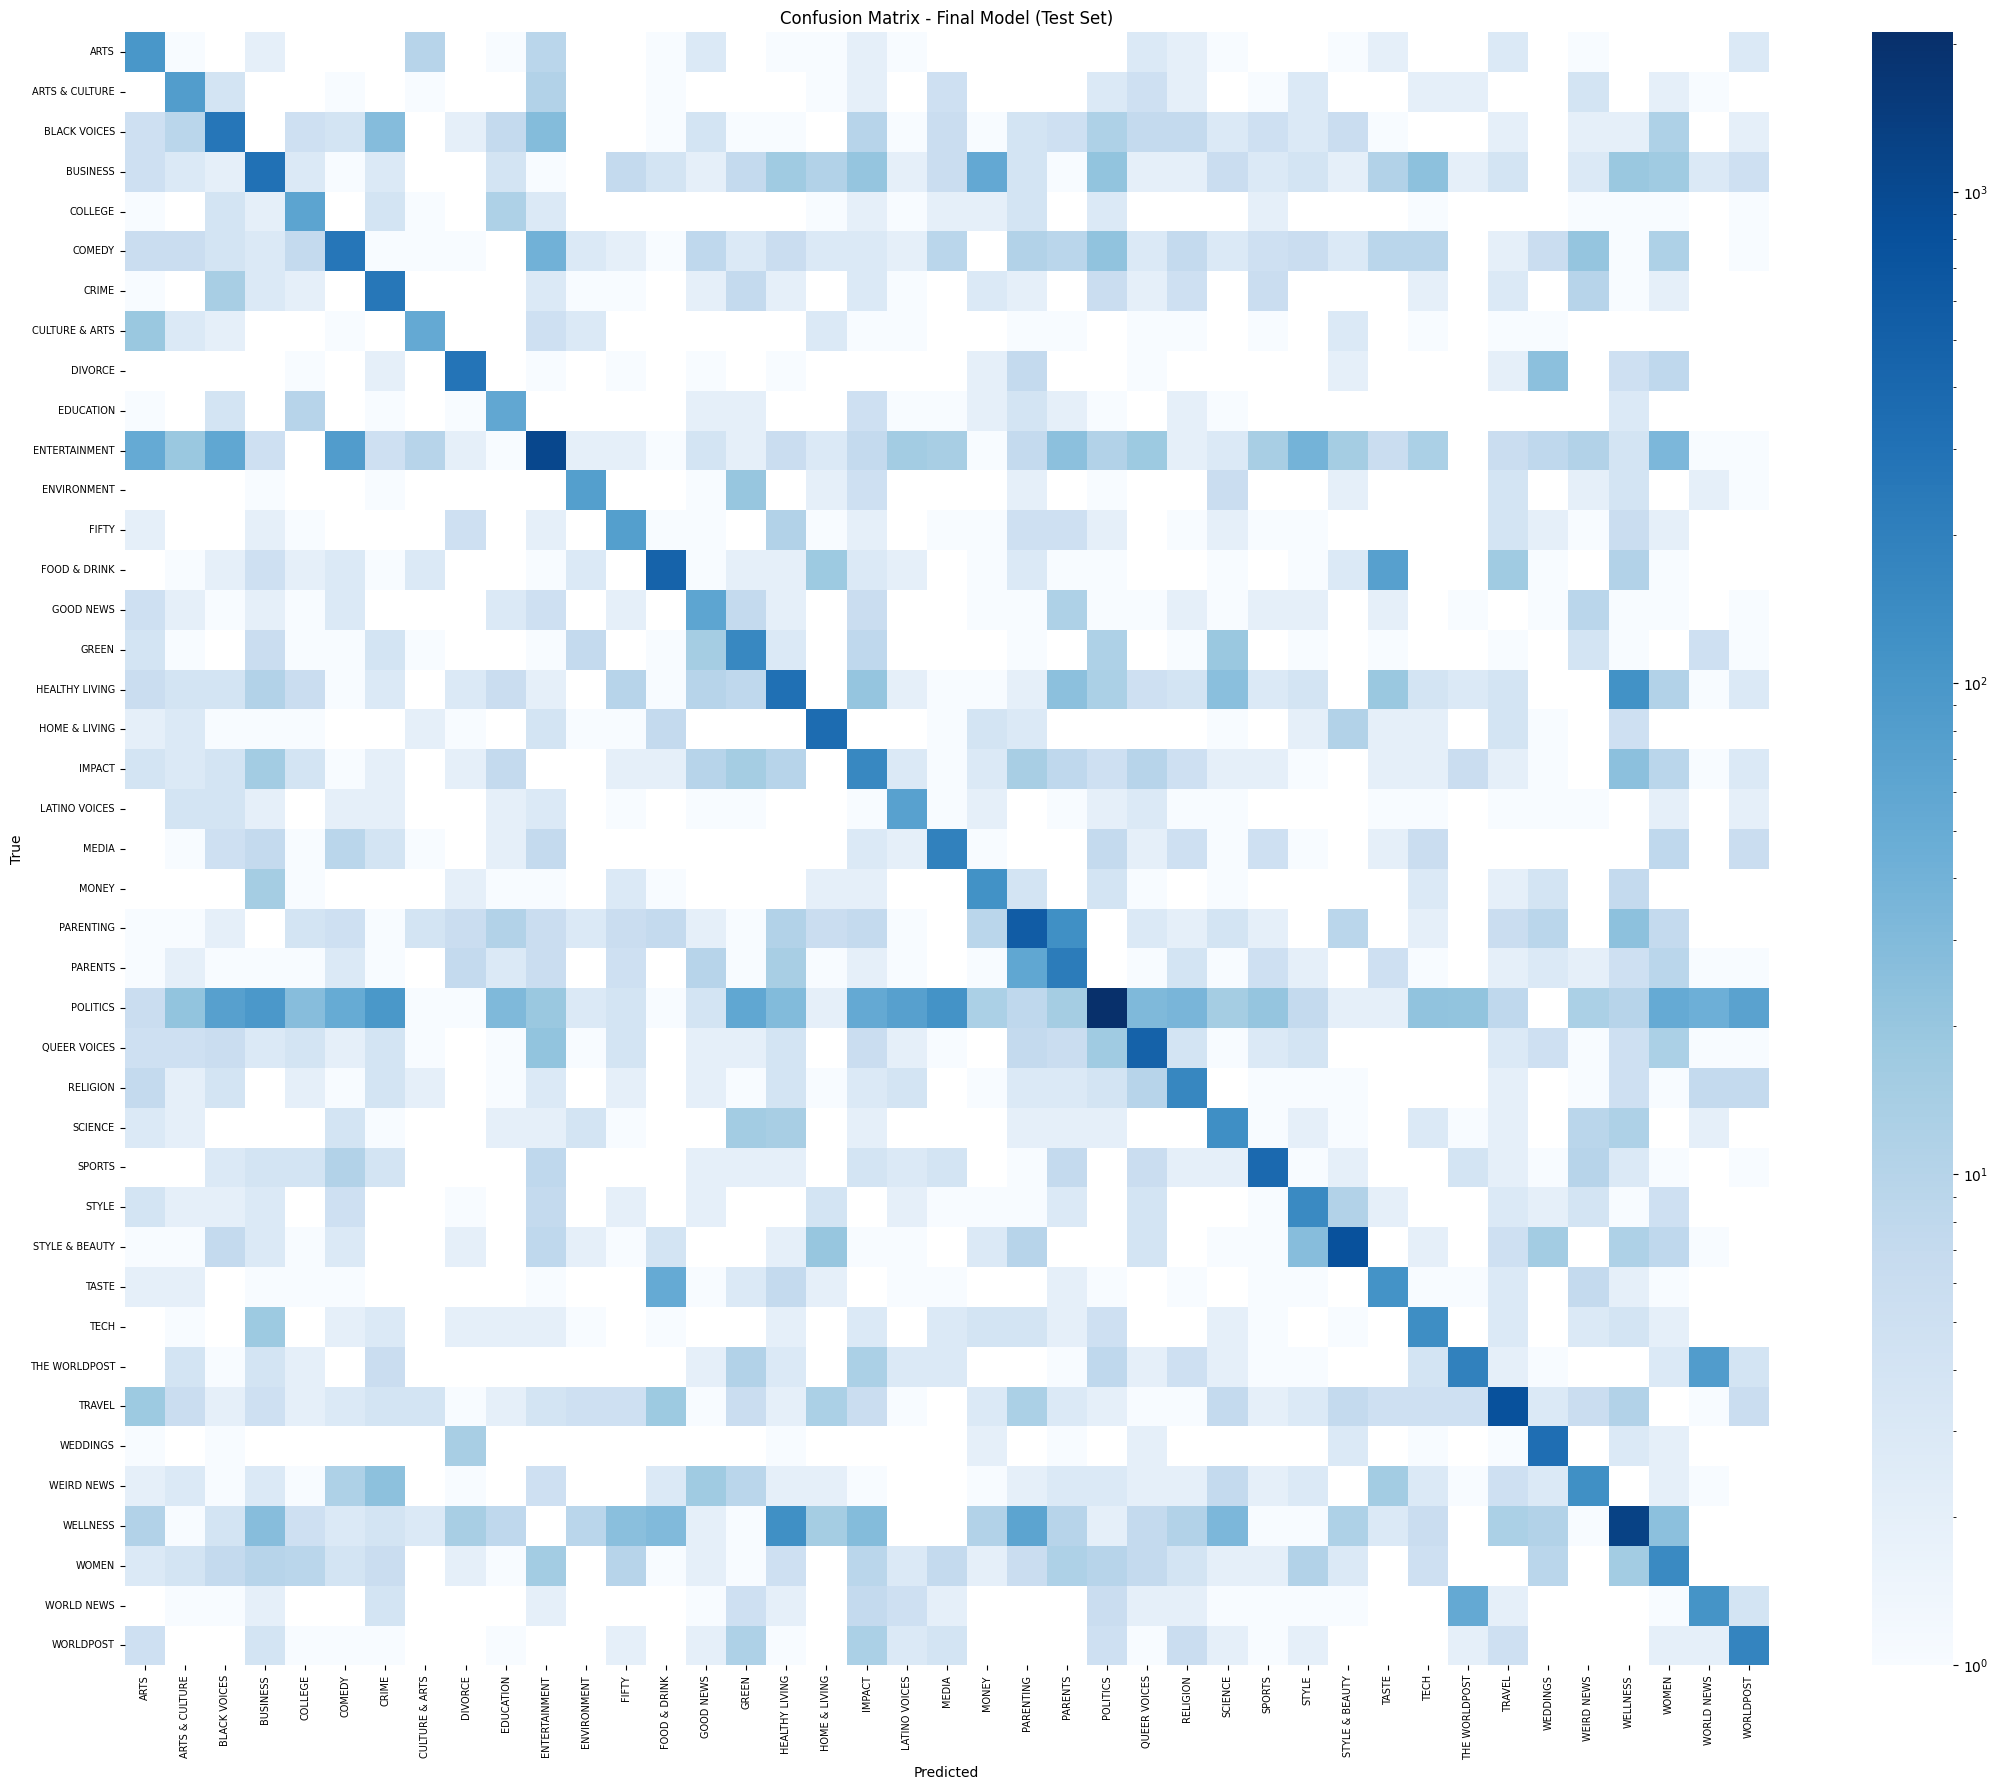

In [42]:
from matplotlib.colors import LogNorm
cm = confusion_matrix(test_data["label"].values, y_pred_final)

plt.figure(figsize=(22, 18))
sns.heatmap(cm,
            annot=False,
            cmap='Blues',
            norm=LogNorm(), # this made the visual better to interpret
            xticklabels=label_enc.classes_,
            yticklabels=label_enc.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Final Model (Test Set)')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

- The matrix reveals that most of the predictions land across the diagonal, which means the model is generally getting the predictions right


- POLITICS has the most spread across other categories since it has the most support. We identified in our EDA process that there were many more samples in this category compared to others.


- This spread of POLITICS makes sense given its similarity and overlap with categories like WORLD NEWS, CRIME, MEDIA, and BUSINESS


- The smaller minority classes like EDUCATION & GOOD NEWS have very faint dianonals, meaning that the  model we built from scratch struggles to properly classify them in their correct category, often misclassifying them as other categories.

#### Print the top 10 most confusion pairs

In [44]:
cm = confusion_matrix(test_data["label"].values, y_pred_final)
cm_df = pd.DataFrame(cm, index=label_enc.classes_, columns=label_enc.classes_)
np.fill_diagonal(cm_df.values, 0)
most_confused = cm_df.unstack().sort_values(ascending=False).reset_index()
most_confused.columns = ['Predicted', 'Actual', 'Count']
print("Top 10 Most Confused Class Pairs:")
print(most_confused.head(10).to_string(index=False))

Top 10 Most Confused Class Pairs:
     Predicted         Actual  Count
       PARENTS      PARENTING    126
HEALTHY LIVING       WELLNESS    124
      WELLNESS HEALTHY LIVING    119
         MEDIA       POLITICS    113
         CRIME       POLITICS     98
      BUSINESS       POLITICS     96
    WORLD NEWS  THE WORLDPOST     86
        COMEDY  ENTERTAINMENT     85
         TASTE   FOOD & DRINK     72
 LATINO VOICES       POLITICS     72


- The top two most confusing class pairs include: PARENTS/PARENTING (126) and HEALTHY LIVING/WELLNESS (124)


- These are nearly identical based on what we saw in the milestone one word frequency plots


- Most of the top 10 confused pairs involve POLITICS absorbing other categories (MEDIA, CRIME, BUSINESS, LATINO VOICES)

    (iii) Any dataset-specific evaluations

- these results reflect a similar pattern to what we saw in the frequency distributions where POLITICS is the most dominant

- we wanted to see after we cleaned the data how much of a gap there is between categoies and there is still a lot of variation

In [45]:
from sklearn.metrics import classification_report

report = classification_report(
    test_data["label"].values,
    y_pred_final,
    target_names=label_enc.classes_,
    output_dict=True)

report_df = pd.DataFrame(report).transpose()
per_class_df = report_df.loc[label_enc.classes_][['precision', 'recall', 'f1-score', 'support']]
per_class_df = per_class_df.sort_values('f1-score', ascending=False)
print(per_class_df.to_string())

                precision    recall  f1-score  support
STYLE & BEAUTY   0.888398  0.845426  0.866379    951.0
TRAVEL           0.860541  0.805668  0.832201    988.0
WEDDINGS         0.744966  0.912329  0.820197    365.0
DIVORCE          0.801700  0.827485  0.814388    342.0
HOME & LIVING    0.760684  0.855769  0.805430    416.0
SPORTS           0.802444  0.807377  0.804903    488.0
QUEER VOICES     0.766193  0.768621  0.767405    631.0
POLITICS         0.915872  0.645872  0.757532   3270.0
FOOD & DRINK     0.767055  0.739968  0.753268    623.0
WELLNESS         0.792536  0.703143  0.745168   1782.0
ENTERTAINMENT    0.819413  0.678505  0.742331   1605.0
PARENTING        0.689367  0.667052  0.678026    865.0
WORLDPOST        0.594684  0.696498  0.641577    257.0
CRIME            0.533058  0.758824  0.626214    340.0
ENVIRONMENT      0.619048  0.590909  0.604651    132.0
RELIGION         0.559727  0.645669  0.599634    254.0
STYLE            0.527972  0.674107  0.592157    224.0
MEDIA     

- STYLE & BEAUTY (0.866), TRAVEL (0.832), WEDDINGS (0.820) are the top performers


- This makes sense, given that they are a bit different from the other categories, so their vocab is less likely to overlap and make the models confused


- GOOD NEWS (0.389), WOMEN (0.403), IMPACT (0.412) are the worst, which makes sense because they are very vague category names, and it might not be super clear what the vocab signal is




- These results show a fairly clear pattern: the specific topic categories do well while the broad/vague ones struggle


## **Step 3 - Final Test Metrics Printout**

In [49]:
f1_weighted = f1_score(test_data["label"].values, y_pred_final, average="weighted")


print("Final Model Test Performance")
print("-" * 45)
print(f"Test Accuracy:     {test_acc_final:.4f}")
print(f"Macro F1:          {f1_final:.4f}")
print(f"Weighted F1:       {f1_weighted:.4f}")
print("-" * 45)

Final Model Test Performance
---------------------------------------------
Test Accuracy:     0.6652
Macro F1:          0.5927
Weighted F1:       0.6741
---------------------------------------------


Compared to the baseline model: DistilBERT Test Accuracy: **0.6386** & Macro F1: **0.5730**, our final model increased accuracy by **0.0266**. While this difference is not massive, our expectation was low given the amount of overlap and imbalance across this dataset. Our macro F1 also improved by about **0.0197**. We tried various experiments to improve accuracy, so we are happy we could increase it even if it's small.